In [20]:
import pandas as pd
import numpy as np

import sys
import os

sys.path.append(os.path.abspath("../src"))

from ebe import Population
import search_space
import data_preprocessing as dp

In [21]:
DATA_ID = 54
SEED = 13

In [22]:
# Load Data
X_train, y_train, X_val, y_val, X_test, y_test = dp.get_preprocessed_data(
        dataset_id=DATA_ID,
        scaling=True,
        random_seed=SEED,
        return_as='tensor',
        task_type='classification',
        categorical_strategy='label', 
        verbose=True
    )

input_size, output_size = dp.get_tensor_sizes(X_train, y_train)

Loading Dataset: vehicle


In [23]:

s_space = search_space.SearchSpace(input_size=input_size, 
                                       output_size=output_size)

In [24]:
import json
starting_path = '../experiments/ebe_vs/v2'
naml_path = os.path.join(starting_path,'naml')
with open(os.path.join(naml_path, f'{DATA_ID}_{SEED}_NAML.json')) as f:
    naml_results = json.load(f)
    naml_time_taken = naml_results["time_taken"]
    naml_max_test_acc = naml_results["test_accuracy_best_non_nn_model"]


with open(os.path.join(starting_path, f'standard/{DATA_ID}_{SEED}_ML.json')) as f:
    standard_results = json.load(f)
    ml_time_taken = standard_results["hist_gradient_boosting_training_time_sec"]
    ml_max_test_acc = standard_results["best_accuracy"]


max_metric = max(naml_max_test_acc, ml_max_test_acc)


In [25]:
naml_max_test_acc

0.8411764705882353

In [26]:
BUDGET_FACTOR = 10
N_INDIVIDUALS = 100
starting_instances = int(0.3 * len(X_train))

time_budget_ebe = max(ml_time_taken * BUDGET_FACTOR, 15)
# percentile_drop = 25
baseline_metric = max_metric
population = Population(s_space, 
                            size=N_INDIVIDUALS,
                            starting_instances=starting_instances,
                            seed=SEED)

ebe_results_final = population.run_ebe(
                            X_train, y_train, X_val, y_val,
                            baseline_metric=baseline_metric,
                            max_generations=150,
                            time_budget=time_budget_ebe,
                            base_drop=0.2,
                            max_drop=0.3,
                            track_all_models=False)
ebe_results_final.head(10)


=== Generation 1 ===
[Prune] Skipped: all candidates protected or under-trained.

=== Generation 2 ===
[Prune] total=100, protected=82, hopeless=11, dropped=11, kept=89

=== Generation 3 ===
[Prune] total=100, protected=74, hopeless=13, dropped=13, kept=87

=== Generation 4 ===
[Prune] total=100, protected=71, hopeless=14, dropped=14, kept=86

=== Generation 5 ===
[Prune] total=100, protected=62, hopeless=22, dropped=22, kept=78

=== Generation 6 ===
[Prune] total=100, protected=64, hopeless=21, dropped=21, kept=79

=== Generation 7 ===
[Prune] total=100, protected=74, hopeless=14, dropped=14, kept=86

=== Generation 8 ===
[Prune] total=100, protected=69, hopeless=16, dropped=16, kept=84
[EBE] Time budget exceeded at gen 9, elapsed=17.03s
EBE process completed.
Training top by ES (fidelity check)


,id,batch_size,n_instances,epochs_trained,batches_trained,efforts,cumulative_times,arch_hidden_layers,arch_shape,arch_depth,...,p_above_goal,forecast_horizon_time,forecast_CI_low,forecast_CI_high,last_train_acc,last_train_loss,last_val_acc,last_val_loss,total_epoch_time,avg_epoch_time
14,93,128,"[162, 226, 316, 442, 540, 540, 540, 540, 540]",8,31,"[0.001997232437133789, 0.001996755599975586, 0...","[0.001997232437133789, 0.003993988037109375, 0...","[68, 68, 68, 68, 68, 68, 68, 68]",constant,8,...,0.576369,0.376963,0.775587,1.0,0.607143,0.744527,0.705882,0.526601,0.133971,0.008373
9,59,1024,"[162, 226, 316, 442, 540, 540, 540, 540, 540]",8,8,"[0.0009999275207519531, 0.0010004043579101562,...","[0.0009999275207519531, 0.0020003318786621094,...","[72, 42]",triangular,2,...,0.546263,0.031001,0.000000,1.0,0.666667,0.848478,0.669118,0.757787,0.021995,0.001375
1,8,512,"[162, 226, 316, 442, 540, 540, 540, 540, 540]",8,12,"[0.001999378204345703, 0.0010030269622802734, ...","[0.001999378204345703, 0.0030024051666259766, ...","[43, 30, 6, 30, 43]",hourglass,4,...,0.540098,0.100955,0.438601,1.0,0.464286,1.080680,0.639706,0.883810,0.041987,0.002624
2,11,1024,"[162, 226, 316, 442, 540, 540, 540, 540, 540]",8,8,"[0.001998424530029297, 0.0029985904693603516, ...","[0.001998424530029297, 0.0049970149993896484, ...","[90, 80, 11, 59]",irregular,4,...,0.537580,0.056498,0.000000,1.0,0.605556,0.842306,0.654412,0.665649,0.033007,0.002063
26,124,128,"[162, 226, 316, 442, 540, 540]",5,16,"[0.0009989738464355469, 0.002000570297241211, ...","[0.0009989738464355469, 0.002999544143676758, ...","[5, 12, 13, 14, 27, 28, 49, 92]",mutated,8,...,0.526792,0.212054,0.410021,1.0,0.607143,0.825295,0.602941,0.894325,0.064048,0.006405
12,75,1024,"[162, 226, 316, 442, 540, 540, 540, 540, 540]",8,8,"[0.0009984970092773438, 0.002001047134399414, ...","[0.0009984970092773438, 0.002999544143676758, ...","[60, 83, 3, 70]",irregular,4,...,0.516286,0.053077,0.000000,1.0,0.346296,1.268412,0.566176,1.141092,0.026204,0.001638
29,129,64,"[162, 226, 316, 442, 540]",4,19,"[0.0020008087158203125, 0.0009999275207519531,...","[0.0020008087158203125, 0.0030007362365722656,...","[84, 56, 52, 44]",pyramid,4,...,0.511392,0.160997,0.398672,1.0,0.551724,0.860624,0.602941,0.934034,0.052014,0.006502
23,120,256,"[162, 226, 316, 442, 540, 540]",5,9,"[0.0030002593994140625, 0.0021200180053710938,...","[0.0030002593994140625, 0.005120277404785156, ...","[41, 41, 41, 68, 68, 68, 68, 68]",mutated,23,...,0.503827,0.157990,0.391536,1.0,0.607143,1.095591,0.573529,1.051404,0.046235,0.004624
69,181,64,"[162, 226, 316]",2,7,"[0.003998756408691406, 0.002998828887939453, 0...","[0.003998756408691406, 0.006997585296630859, 0...","[96, 92, 80, 76, 72, 72, 35, 67, 66, 65, 71, 7...",mutated,24,...,0.478616,0.189011,0.374452,1.0,0.441176,1.296108,0.500000,1.250807,0.047994,0.011999
75,187,32,"[162, 226]",1,6,"[0.0009996891021728516, 0.002001047134399414, ...","[0.0009996891021728516, 0.0030007362365722656,...","[27, 5, 93]",irregular,3,...,0.470345,0.180042,0.000000,1.0,0.000000,1.579907,0.433824,1.285498,0.020007,0.010003


In [27]:
# Train by ES the best model
population.final_decision()

{'ShouldYouEvenNN?': False,
 'Exp. Utility': -0.09412635052029299,
 'p_above_goal': 0.5763686312396752,
 'benefit': 0.06452442653874269,
 'cost': 0.30997753143310547}

In [28]:
display(ebe_results_final.iloc[0].T)

id                                                                           93
batch_size                                                                  128
n_instances                       [162, 226, 316, 442, 540, 540, 540, 540, 540]
epochs_trained                                                                8
batches_trained                                                              31
efforts                       [0.001997232437133789, 0.001996755599975586, 0...
cumulative_times              [0.001997232437133789, 0.003993988037109375, 0...
arch_hidden_layers                             [68, 68, 68, 68, 68, 68, 68, 68]
arch_shape                                                             constant
arch_depth                                                                    8
arch_activation_fn                   <class 'torch.nn.modules.activation.Tanh'>
arch_dropout_rate                                                           0.1
arch_optimizer_type                     

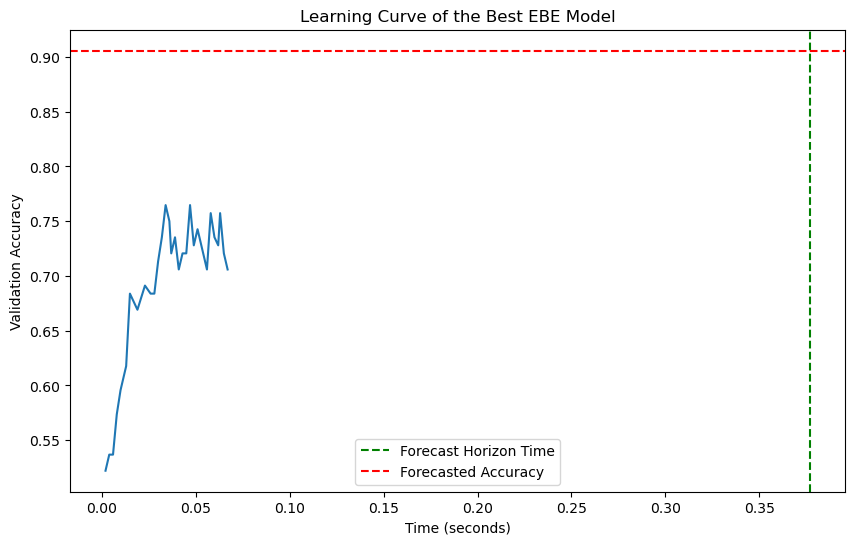

In [29]:
# plot the lc of the best model 
row = ebe_results_final.iloc[0]
ebe_id = row['id']

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.lineplot(x=row['cumulative_times'], y=row['val_acc'])
plt.title('Learning Curve of the Best EBE Model')
plt.xlabel('Time (seconds)')
plt.ylabel('Validation Accuracy')
plt.axvline(x=row["forecast_horizon_time"], color='g', linestyle='--', label='Forecast Horizon Time')

forecast = row['forecasted_val_acc']
plt.axhline(y=forecast, color='r', linestyle='--', label='Forecasted Accuracy')
plt.legend()

Forecast fidelity report:
  MAE : 0.1523236883397336
  Bias: -0.03181615234904001
     id  forecasted_val_acc  fidelity_val_acc     delta
36  107            0.325899          0.750000  0.424101
28   60            0.399431          0.735294  0.335863
38  155            0.272559          0.602941  0.330383
27  182            0.405838          0.720588  0.314750
24  136            0.459235          0.683824  0.224589
37  115            0.304399          0.500000  0.195601
35    7            0.331636          0.463235  0.131599
16  151            0.574002          0.691176  0.117174
19  103            0.496345          0.610294  0.113949
20  110            0.496194          0.558824  0.062629
23  158            0.462871          0.522059  0.059187
18  111            0.542489          0.566176  0.023687
31  169            0.354691          0.367647  0.012956
21   87            0.481868          0.485294  0.003427
10  181            0.749520          0.735294 -0.014225
22  143            0.4

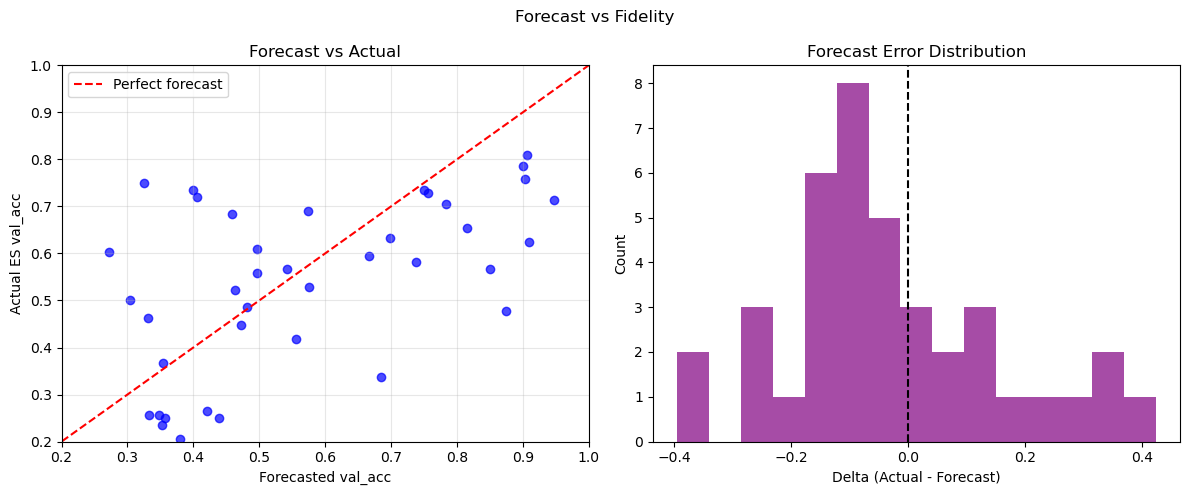

In [30]:
fidelity_ledger = population.fidelity_ledger
report = population.compare_forecast_vs_fidelity()

print("Forecast fidelity report:")
print("  MAE :", report["MAE"])
print("  Bias:", report["Bias"])
print(report["details"])

from utils_viz import plot_forecast_vs_fidelity
plot_forecast_vs_fidelity(report, title="Forecast vs Fidelity")


In [31]:
# Loc a specific ID
fidelity_ledger.loc[fidelity_ledger['id'] == ebe_id]

,id,forecasted_val_acc,forecast_horizon_time,fidelity_val_acc,fidelity_train_acc,fidelity_val_loss,learning_curve
2,93,0.905701,0.376963,0.808824,0.945312,0.533753,"{'es_train_losses': [1.5284206867218018, 1.436..."


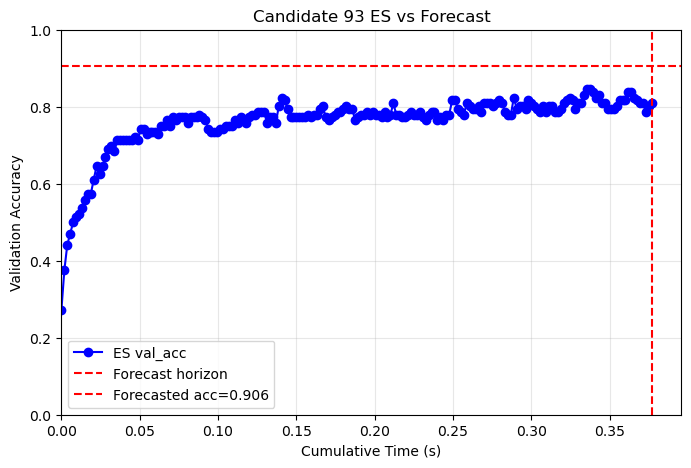

In [32]:
from utils_viz import plot_es_learning_curve_from_ledger
cand_id = ebe_id
row = fidelity_ledger[fidelity_ledger["id"] == cand_id].iloc[0]
plot_es_learning_curve_from_ledger(row)


In [33]:
row

id                                                                      93
forecasted_val_acc                                                0.905701
forecast_horizon_time                                             0.376963
fidelity_val_acc                                                  0.808824
fidelity_train_acc                                                0.945312
fidelity_val_loss                                                 0.533753
learning_curve           {'es_train_losses': [1.5284206867218018, 1.436...
Name: 2, dtype: object